# AI Job Market Intelligence

## 5. Exploratory Data Analysis

### Objective

To identify patterns, trends, relationships and business insights
from the AI job market dataset.

### Business Areas

- Overall AI job market
- Salary
- Job roles
- Skills
- Experience
- Demand
- Remote work
- Companies
- Countries
- LLM / Generative AI
- Market trends


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns",None)

In [2]:
df = pd.read_csv("../data/processed/ai_jobs_feature_engineered.csv")
df.head()

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier,experience_group,salary_band,salary_range_usd,is_fully_remote,posting_quarter,requires_python,requires_sql,requires_machine_learning,requires_deep_learning,requires_generative_ai,salary_per_experience,is_remote_work
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7.0,Master's,239000.0,155000,290000,Boston,Usa,On-Site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,NaN,16.9,6.8,2026,3,1,0,1,Senior ($200-300k),Senior Level,Very High,135000,False,Q<NA>,True,True,False,False,False,34142.857143,False
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2.0,Bachelor's,166000.0,90000,200000,London,Uk,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NL...,5.4,NaN,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k),NaN,Very High,110000,False,Q<NA>,True,False,False,False,False,83000.000000,True
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4.0,Associate's,360000.0,160000,300000,Seattle,Usa,Fully Remote,Big Tech (FAANG+),Finance,Vector DBs|Python|Prompt Engineering|Fine-tuni...,9.1,NaN,42.7,7.7,2026,1,1,1,1,Elite (>$300k),Mid Level,Very High,140000,False,Q<NA>,True,False,False,False,False,90000.000000,False
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3.0,Bachelor's,161000.0,130000,220000,Singapore,Singapore,Fully Remote,SME (51-500),Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,12.0,NaN,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k),Mid Level,Very High,90000,False,Q<NA>,True,True,False,False,False,53666.666667,False
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5.0,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,Usa,Fully Remote,Enterprise (5000+),Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,9.4,NaN,17.3,8.9,2026,1,1,1,0,Senior ($200-300k),Mid Level,Very High,120000,False,Q<NA>,False,False,False,False,False,56600.000000,False


In [3]:
df.shape

(1500, 37)

In [4]:
df.columns

Index(['job_id', 'job_title', 'job_category', 'experience_level',
       'years_of_experience', 'education_required', 'annual_salary_usd',
       'salary_min_usd', 'salary_max_usd', 'city', 'country', 'remote_work',
       'company_size', 'industry', 'required_skills', 'ai_salary_premium_pct',
       'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10',
       'posting_year', 'posting_month', 'is_senior', 'is_remote_friendly',
       'is_llm_role', 'salary_tier', 'experience_group', 'salary_band',
       'salary_range_usd', 'is_fully_remote', 'posting_quarter',
       'requires_python', 'requires_sql', 'requires_machine_learning',
       'requires_deep_learning', 'requires_generative_ai',
       'salary_per_experience', 'is_remote_work'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 37 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   job_id                     1500 non-null   object 
 1   job_title                  1500 non-null   object 
 2   job_category               1500 non-null   object 
 3   experience_level           1500 non-null   object 
 4   years_of_experience        1500 non-null   float64
 5   education_required         1500 non-null   object 
 6   annual_salary_usd          1500 non-null   float64
 7   salary_min_usd             1500 non-null   int64  
 8   salary_max_usd             1500 non-null   int64  
 9   city                       1500 non-null   object 
 10  country                    1500 non-null   object 
 11  remote_work                1500 non-null   object 
 12  company_size               1500 non-null   object 
 13  industry                   1500 non-null   objec

In [6]:
df.describe()

,years_of_experience,annual_salary_usd,salary_min_usd,salary_max_usd,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_range_usd,salary_per_experience
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,0.0,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,6.216000,194892.000000,135448.666667,257537.333333,10.858200,NaN,31.116333,7.897333,2025.584000,3.968000,0.496667,0.754000,0.218000,122088.666667,39276.418925
std,2.675216,66506.822013,24448.950878,39852.822207,4.029742,NaN,22.046343,1.102846,0.493058,3.270388,0.500156,0.430822,0.413025,27184.115257,26721.779915
min,1.000000,90000.000000,90000.000000,180000.000000,3.000000,NaN,5.000000,6.000000,2025.000000,1.000000,0.000000,0.000000,0.000000,57000.000000,10000.000000
25%,4.000000,144750.000000,120000.000000,218000.000000,8.200000,NaN,15.375000,6.900000,2025.000000,2.000000,0.000000,1.000000,0.000000,110000.000000,21770.833333
50%,6.000000,180000.000000,140000.000000,270000.000000,10.500000,NaN,23.400000,7.900000,2026.000000,3.000000,0.000000,1.000000,0.000000,130000.000000,31612.500000
75%,8.000000,236250.000000,155000.000000,290000.000000,14.200000,NaN,42.700000,8.900000,2026.000000,5.000000,1.000000,1.000000,0.000000,140000.000000,48000.000000
max,15.000000,384000.000000,180000.000000,320000.000000,18.000000,NaN,87.800000,9.800000,2026.000000,12.000000,1.000000,1.000000,1.000000,165000.000000,240000.000000


## Overall Market Analysis

In [7]:
# Q1. How many total AI job postings are there?
total_jobs = df["job_id"].nunique()
print("Total Job Postings:", total_jobs)

Total Job Postings: 1500


In [8]:
# Q2. What is the average annual salary?
avg_salary = df["annual_salary_usd"].mean()
print("Average Salary: $", round(avg_salary,2))

Average Salary: $ 194892.0


In [9]:
# Q3. What is the median annual salary?
median_salary = df["annual_salary_usd"].median()
print("Median Salary: $", round(median_salary, 2))

Median Salary: $ 180000.0


In [10]:
# Q4. What is the average years of experience required?
avg_experience = df["years_of_experience"].mean()
print("Average Experience:", round(avg_experience, 2), "year")

Average Experience: 6.22 year


## Job Role Analysis

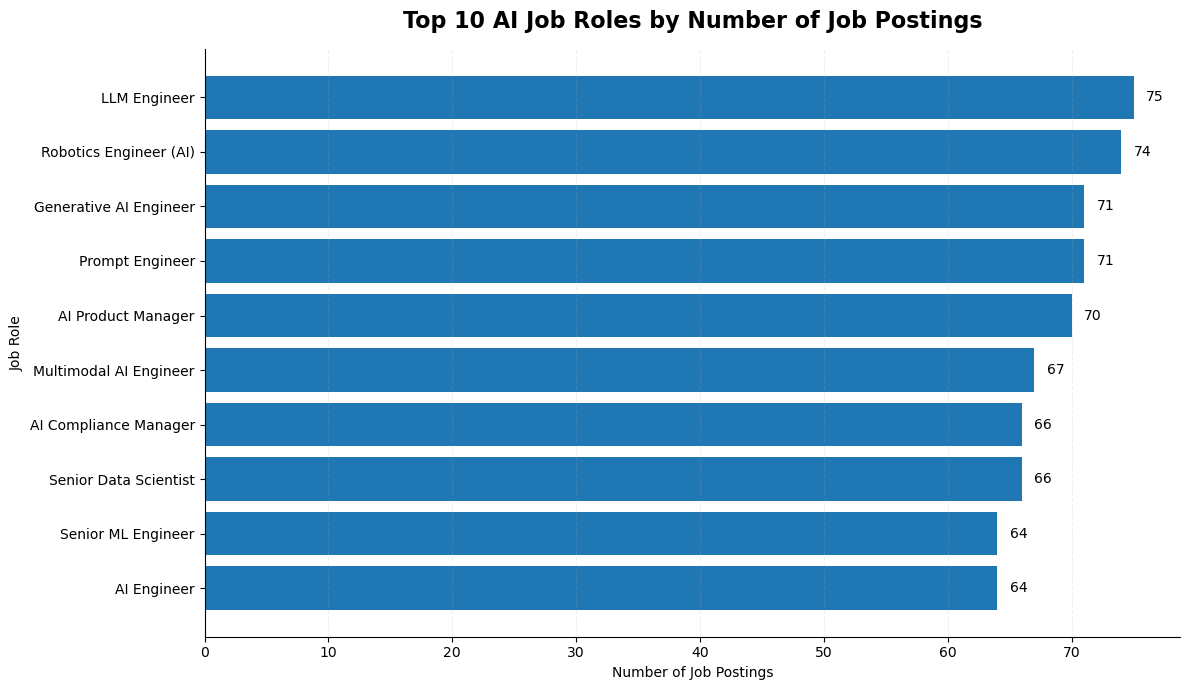

In [11]:
# Q5. What are the top 10 most common AI job roles?
top_roles = (
    df["job_title"]
    .value_counts() 
    .head(10)
    .sort_values(ascending=True)
)



plt.figure(figsize=(12,7))

bars = plt.barh(
    top_roles.index,
    top_roles.values
)

plt.title(
    "Top 10 AI Job Roles by Number of Job Postings", 
    fontsize=16,
    fontweight="bold",
    pad=15

)
plt.xlabel("Number of Job Postings", fontsize=10)
plt.ylabel("Job Role", fontsize=10)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.2
)

for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value)}",
        va="center",
        fontsize=10
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

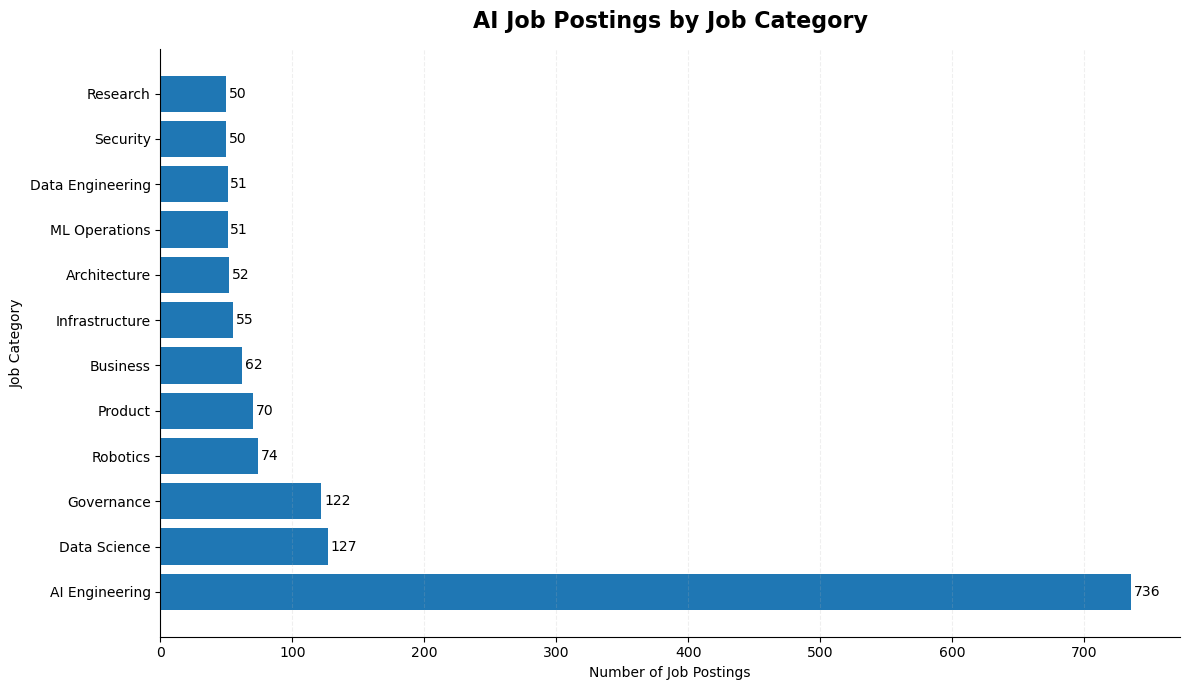

In [12]:
# Q6. Which job categories have the most job postings?
category_jobs = (
    df["job_category"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,7))

bars = plt.barh(
    category_jobs.index,
    category_jobs.values
)

plt.title(
    "AI Job Postings by Job Category",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Number of Job Postings",
    fontsize=10 
)
plt.ylabel(
    "Job Category",
    fontsize=10
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.2
)

for bar in bars:
    value = bar.get_width()
    plt.text(
        value + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value):,}",
        va="center",
        fontsize=10
    )
    
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

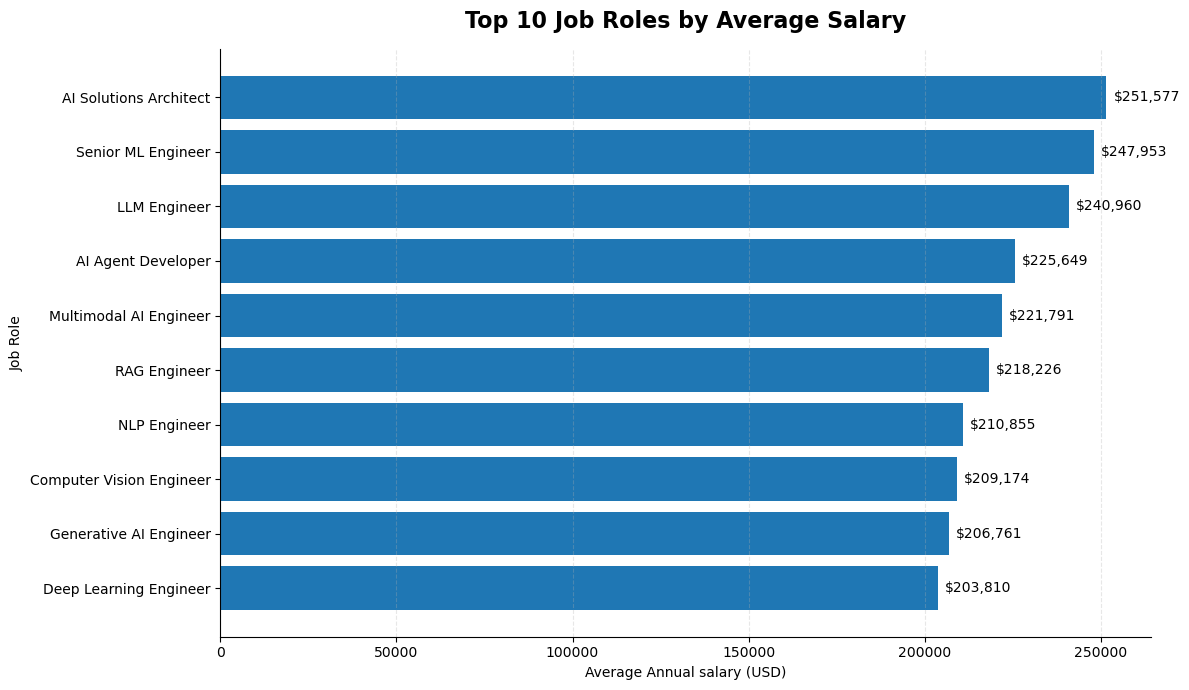

In [36]:
# Q7. Which job roles have the highest average salary?
avg_salary_roles = (
    df.groupby("job_title")["annual_salary_usd"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)


plt.figure(figsize=(12,7))

plt.gca().invert_yaxis()
bars = plt.barh(
    avg_salary_roles.index,
    avg_salary_roles.values
)

plt.title(
    "Top 10 Job Roles by Average Salary",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Average Annual salary (USD)",
    fontsize=10
)

plt.ylabel(
    "Job Role",
    fontsize=10
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

for bar in bars:
    salary = bar.get_width()
    plt.text(
        salary + 2000,
        bar.get_y() + bar.get_height()/2,
        f"${salary:,.0f}",
        va="center",
        fontsize=10
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

<Figure size 1000x700 with 0 Axes>

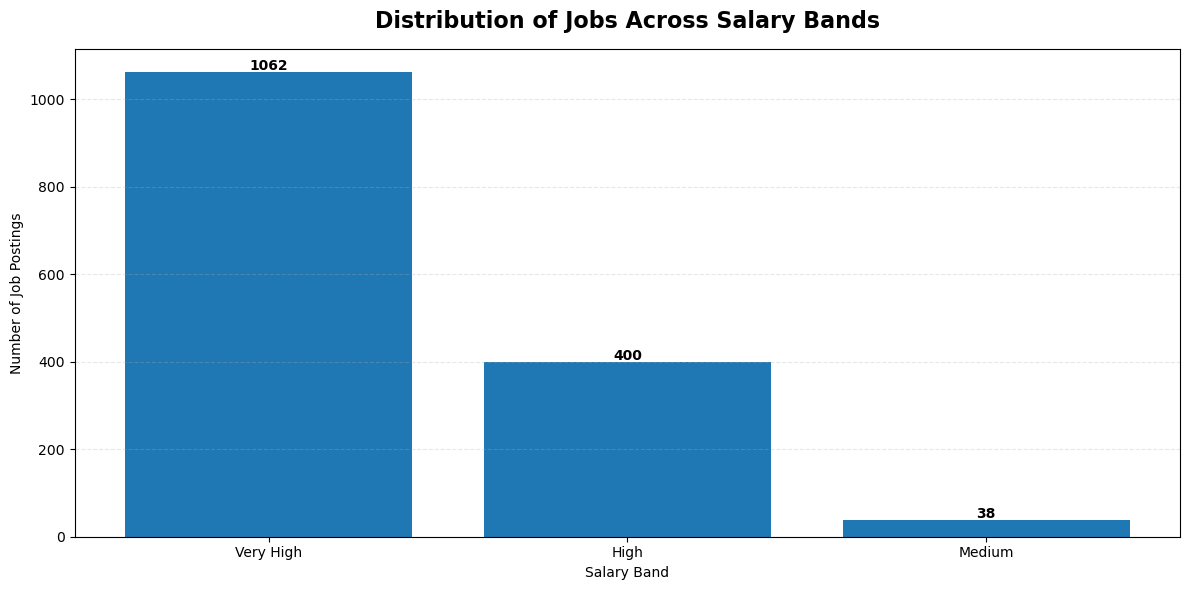

In [14]:
# Q8. What is the distribution of jobs across salary bands?
salary_band_counts = (
    df["salary_band"]
    .value_counts()
)


plt.figure(figsize=(10,7))

plt.figure(figsize=(12,6))

bars = plt.bar(
    salary_band_counts.index,
    salary_band_counts.values
)

plt.title(
    "Distribution of Jobs Across Salary Bands",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Salary Band",
    fontsize=10
)

plt.ylabel(
    "Number of Job Postings",
    fontsize=10
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 5,
        f"{int(value)}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )
    


plt.tight_layout()
plt.show()

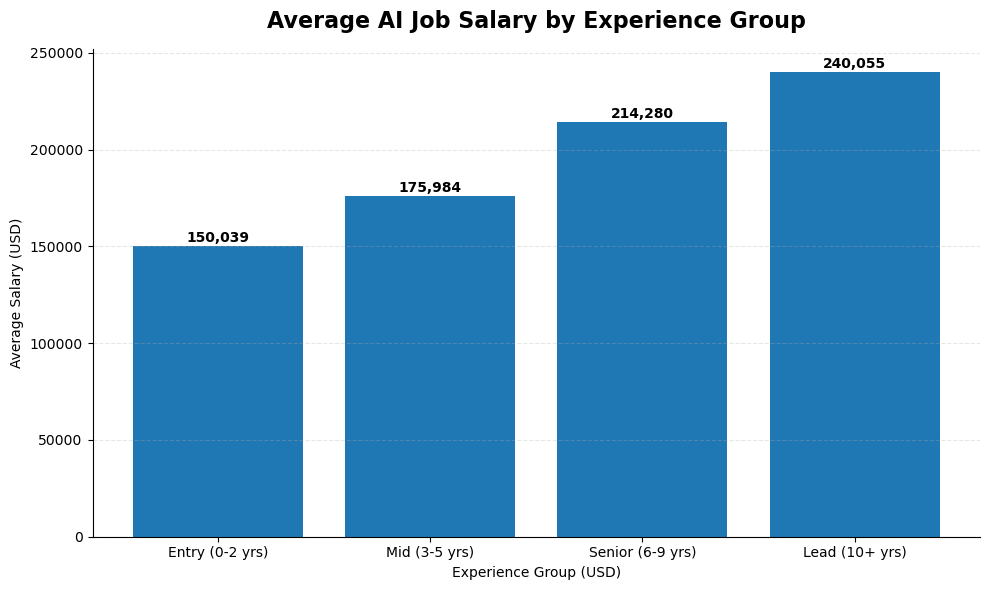

In [88]:
# Q9. How does the average salary change across different experience groups?
salary_experience = (
    df.groupby("experience_level")["annual_salary_usd"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    salary_experience.index,
    salary_experience.values,
    
)
plt.title(
    "Average AI Job Salary by Experience Group",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Experience Group (USD)",
    fontsize=10
)

plt.ylabel(
    "Average Salary (USD)",
    fontsize=10
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)


for bar in bars:
    salary = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        salary + 2000,
        f"{salary:,.0f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )
    
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Correlation: 0.08


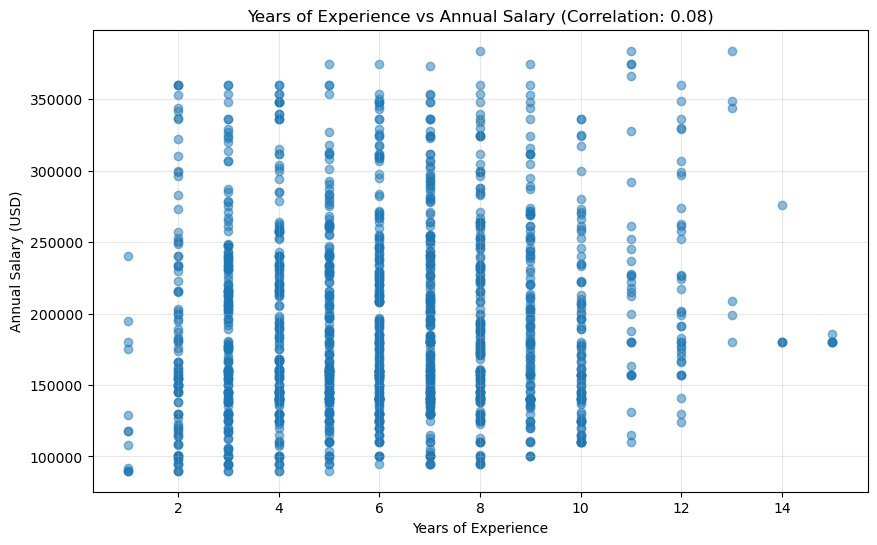

In [49]:
# 10. What is the relationship between years of experience and annual salary?
experience_salary = df[
    ["years_of_experience", "annual_salary_usd"]
].dropna()

# Calculate correlation
correlation = experience_salary[
    "years_of_experience"
].corr(
    experience_salary["annual_salary_usd"]
)
print(f"Correlation: {correlation:.2f}")

plt.figure(figsize=(10,6))

plt.scatter(
    experience_salary["years_of_experience"],
    experience_salary["annual_salary_usd"],
    alpha=0.5
)
plt.xlabel("Years of Experience")
plt.ylabel("Annual Salary (USD)")
plt.title(
    f"Years of Experience vs Annual Salary "
    f"(Correlation: {correlation:.2f})"
)
plt.grid(True, alpha=0.3)

plt.show()

## Country Analysis

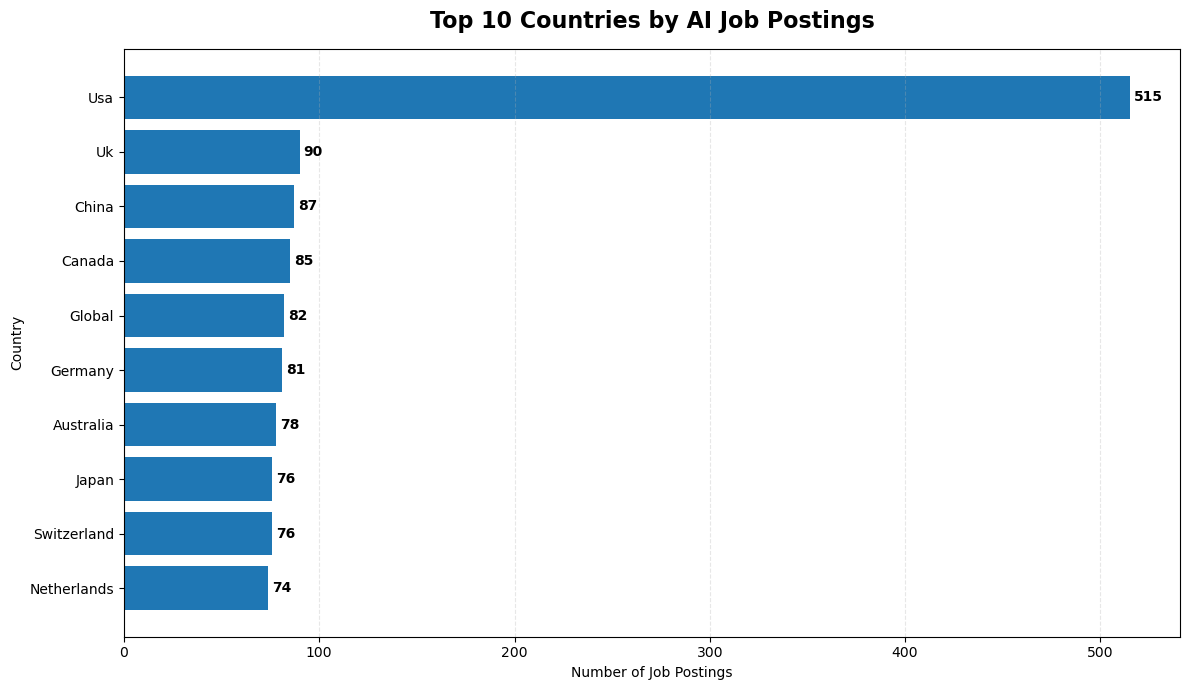

In [ ]:
# 11. Which are the top 10 countries with the highest number of AI job postings? 

country_jobs = df["country"].value_counts().head(10).sort_values(ascending=True)
country_jobs

plt.figure(figsize=(12,7))

bars = plt.barh(
    country_jobs.index,
    country_jobs.values
    
)

plt.title(
    "Top 10 Countries by AI Job Postings",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Number of Job Postings",
    fontsize=10
)
plt.ylabel(
    "Country",
    fontsize=10
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

for bar in bars:
    value = bar.get_width()
    plt.text(
      value + 2,
      bar.get_y() + bar.get_height() / 2,
      f"{int(value)}",
      va="center",
      fontsize=10,
      fontweight="bold"
    )
    

plt.tight_layout()
plt.show()


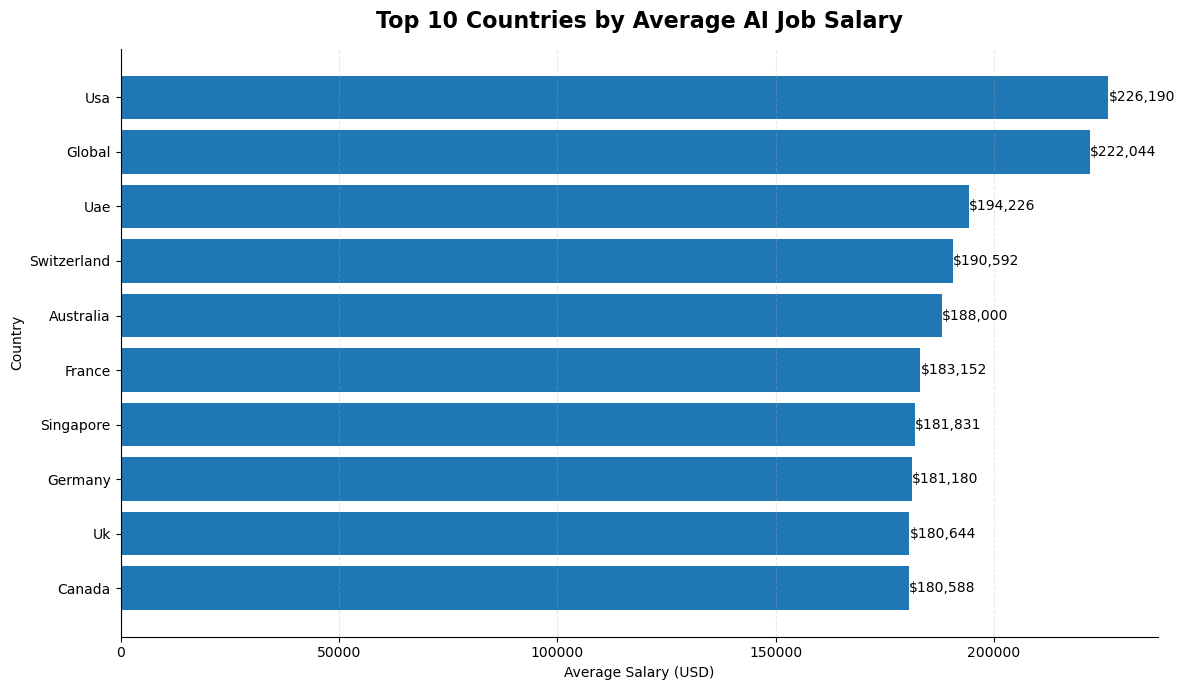

In [ ]:
# 12. Which countries have the highest average AI job salaries?
country_salary = (
    df.groupby("country")
    .agg(
        avg_salary = ("annual_salary_usd", "mean"),
        job_count = ("job_id", "count")
    )
)
country_salary = (
    country_salary[country_salary["job_count"] >= 10]
    .sort_values("avg_salary", ascending=False)
    .head(10)
)
country_salary

plt.figure(figsize=(12,7))

bars = plt.barh(
    country_salary.index,
    country_salary["avg_salary"]
)

plt.title(
    "Top 10 Countries by Average AI Job Salary",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Average Salary (USD)",
    fontsize=10
)

plt.ylabel(
    "Country",
    fontsize=10
)

plt.gca().invert_yaxis()

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

for bar in bars:
    salary = bar.get_width()
    plt.text(
        salary + 2,
        bar.get_y() + bar.get_height() / 2,
        f"${salary:,.0f}",
        va="center",
        fontsize=10
    )
    
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Q13. How does AI job salary distribution vary across different countries?

salary_country = df[
    ["country", "annual_salary_usd"]
].copy()

# remove missing values 
salary_country = salary_country.dropna(
    subset = ["country", "annual_salary_usd"]
)

# Find the top 10 countries by number of job postings
top_10_countries = (
    salary_country["country"]
    .value_counts()
    .head(10)
    .index
)

# keep only the top 10 countries
salary_country_top10 = salary_country[
    salary_country["country"].isin(top_10_countries)
]

# Display salary statistics
salary_summary = (
    salary_country_top10
    .groupby("country")["annual_salary_usd"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
    .sort_values("median", ascending=False)
)
print("Salary Distribution Across Top 10 Countries:\n")
print(salary_summary)

Salary Distribution Across Top 10 Countries:

             count           mean    median       min       max
country                                                        
Global          82  222043.902439  221000.0  105000.0  360000.0
Usa            515  226189.902913  219000.0   90000.0  384000.0
Australia       78  188000.000000  180500.0   95000.0  353000.0
Germany         81  181180.246914  173000.0   95000.0  360000.0
Uk              90  180644.444444  167500.0   95000.0  360000.0
Switzerland     76  190592.105263  167500.0  100000.0  354000.0
Netherlands     74  175256.756757  160000.0   98000.0  348000.0
Canada          85  180588.235294  159000.0   98000.0  384000.0
Japan           76  170131.578947  158500.0   95000.0  336000.0
China           87  134287.356322  140000.0   90000.0  180000.0


<Figure size 1200x700 with 0 Axes>

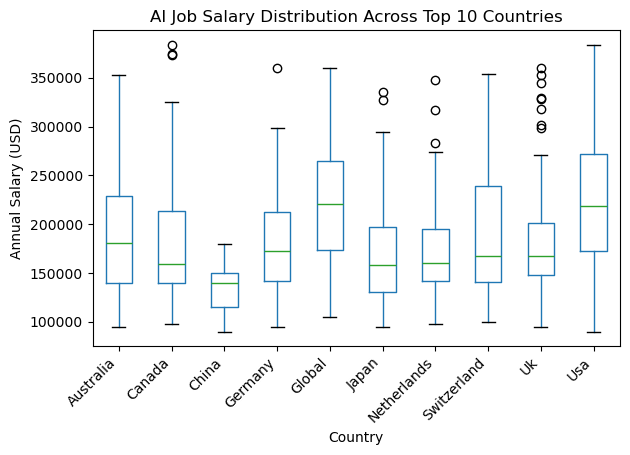

In [76]:
plt.figure(figsize=(12, 7))

salary_country_top10.boxplot(
    column="annual_salary_usd",
    by="country",
    grid=False
)

plt.title("AI Job Salary Distribution Across Top 10 Countries")
plt.suptitle("")

plt.xlabel("Country")
plt.ylabel("Annual Salary (USD)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# Remote Work

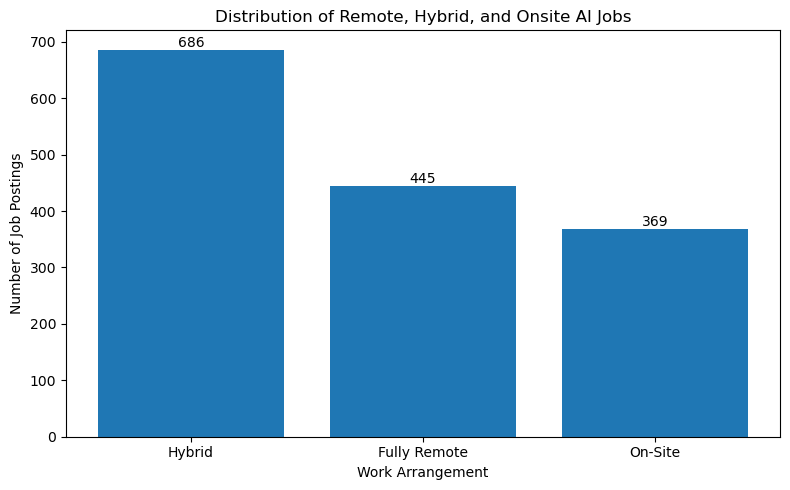

In [ ]:
#14.  What is the distribution of Remote, Hybrid, and Onsite AI jobs? 

remote_distribution = (
    df["remote_work"]
    .value_counts()
    
)

plt.figure(figsize=(8,5))
bars = plt.bar(
    remote_distribution.index,
    remote_distribution.values
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )
plt.xlabel("Work Arrangement")
plt.ylabel("Number of Job Postings")
plt.title("Distribution of Remote, Hybrid, and Onsite AI Jobs")

plt.tight_layout()
plt.show()

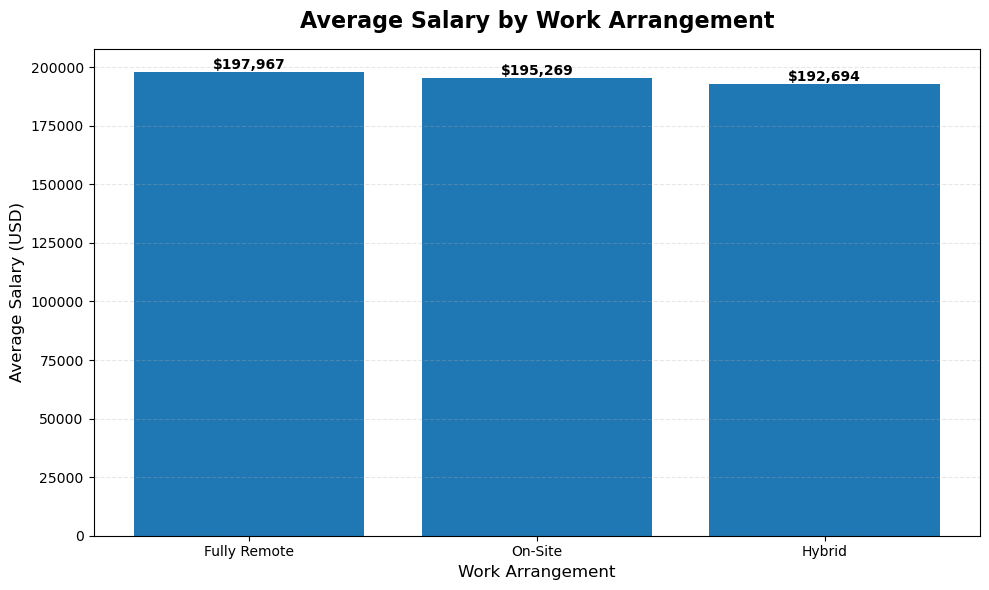

In [85]:
# 15.  What is the average salary for Remote, Hybrid, and Onsite jobs?
remote_salary = (
    df.groupby("remote_work")["annual_salary_usd"]
    .mean()
    .sort_values(ascending=False)
)
remote_salary

plt.figure(figsize=(10,6))

bars = plt.bar(
    remote_salary.index,
    remote_salary.values
)

plt.title(
    "Average Salary by Work Arrangement",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Work Arrangement",
    fontsize=12
)

plt.ylabel(
    "Average Salary (USD)",
    fontsize=12
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bar in bars:
    salary = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        salary,
        f"${salary:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
        
    )
    
plt.tight_layout()
plt.show()


# Skills Analysis

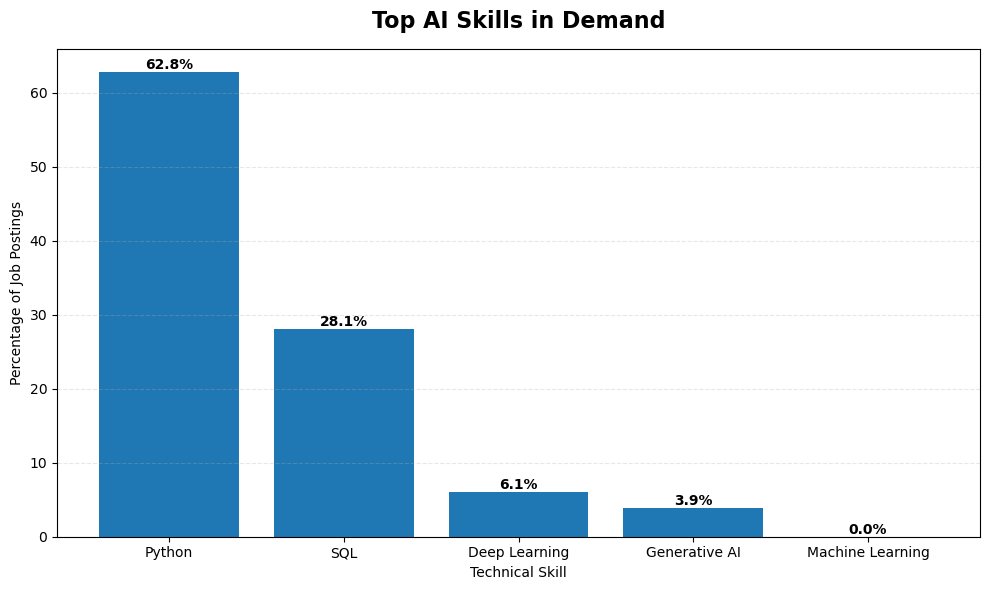

In [ ]:
# 16. Which technical skills are most frequently required for AI jobs?

skill_columns = [
    "requires_python",
    "requires_sql",
    "requires_machine_learning",
    "requires_deep_learning",
    "requires_generative_ai"
]

df[skill_columns].head()

# calculate skill demand

skill_demand = {}
for skill in skill_columns:
    skill_demand[skill] = df[skill].mean() * 100

skill_demand = pd.Series(skill_demand).sort_values( ascending=False)

# Rename skills for better readability

skill_names = {
    "requires_python": "Python",
    "requires_sql": "SQL",
    "requires_machine_learning": "Machine Learning",
    "requires_deep_learning": "Deep Learning",
    "requires_generative_ai": "Generative AI"
}

skill_demand.index = skill_demand.index.map(skill_names)

# Create Chart

plt.figure(figsize=(10,6))

bars = plt.bar(
    skill_demand.index,
    skill_demand.values
)

plt.title(
    "Top AI Skills in Demand",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Technical Skill",
    fontsize=10
)

plt.ylabel(
    "Percentage of Job Postings",
    fontsize=10
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize="10",
        fontweight="bold"
        
    )
    
plt.tight_layout()
plt.show()

# LLM / GenAI Analysis

In [ ]:
# 17. How many LLM or Generative AI-related jobs are there in the dataset?

llm_jobs = df["is_llm_role"].sum()

total_jobs = len(df)

llm_percentage = (
    llm_jobs / total_jobs
) * 100

print("Total Jobs:", total_jobs)
print("LLM / GenAI Jobs:", llm_jobs)
print("LLM / GenAI Job Percentage:", round(llm_percentage, 2), "%")

Total Jobs: 1500
LLM / GenAI Jobs: 327
LLM / GenAI Job Percentage: 21.8 %


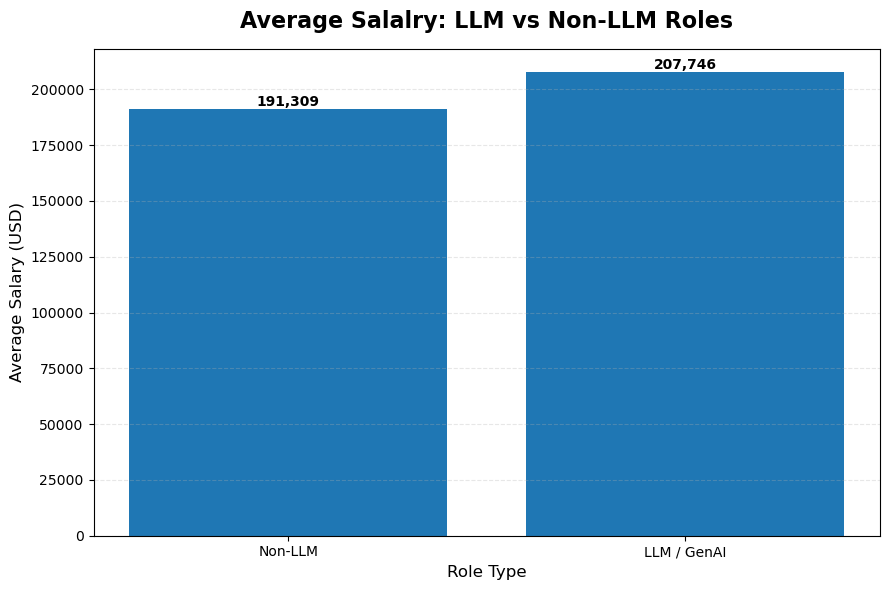

In [ ]:
# 18. How does the average salary of LLM/GenAI jobs compare with non-LLM jobs?
llm_salary = (
    df.groupby("is_llm_role")["annual_salary_usd"].mean()
)
llm_salary.index = [
    "Non-LLM",
    "LLM / GenAI"
]



plt.figure(figsize=(9,6))

bars = plt.bar(
    llm_salary.index,
    llm_salary.values
)

plt.title(
    "Average Salalry: LLM vs Non-LLM Roles",
    fontsize=16,
    fontweight="bold",
    pad=15

)
plt.xlabel(
    "Role Type",
    fontsize=12
    
)
plt.ylabel(
    "Average Salary (USD)",
    fontsize=12
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bar in bars:
    salary = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        salary,
        f"{salary:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )
    
plt.tight_layout()
plt.show()

# Job Market Trend

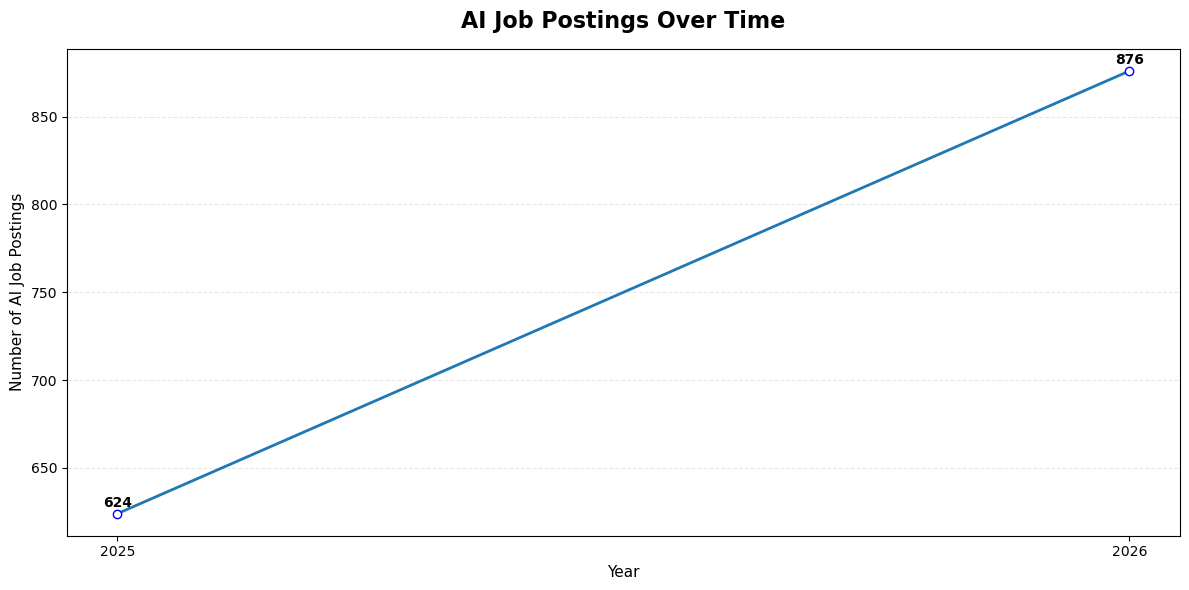

In [86]:
# 19. AI job postings time ke saath kaise change hui?
yearly_jobs = (
    df.groupby("posting_year").size().sort_index()
)
yearly_jobs

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_jobs.index,
    yearly_jobs.values,
    marker="o",
    linewidth=2,
    markersize=6,
    markerfacecolor="white",
    markeredgecolor="blue"
    
)

plt.title(
    "AI Job Postings Over Time",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Year",
    fontsize=11
)

plt.ylabel(
    "Number of AI Job Postings",
    fontsize=11
)

for year, jobs in zip(yearly_jobs.index, yearly_jobs.values):
    plt.text(
        year,
        jobs + 4,
        f"{jobs:,}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )
    
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.xticks(yearly_jobs.index)

plt.tight_layout()
plt.show()

,years_of_experience,annual_salary_usd,salary_min_usd,salary_max_usd,demand_score,demand_growth_yoy_pct,benefits_score_10
years_of_experience,1.00,0.08,0.25,0.17,NaN,-0.12,-0.04
annual_salary_usd,0.08,1.00,0.42,0.43,NaN,0.14,-0.01
salary_min_usd,0.25,0.42,1.00,0.74,NaN,0.18,-0.01
salary_max_usd,0.17,0.43,0.74,1.00,NaN,0.30,-0.00
demand_score,NaN,NaN,NaN,NaN,NaN,NaN,NaN
demand_growth_yoy_pct,-0.12,0.14,0.18,0.30,NaN,1.00,-0.02
benefits_score_10,-0.04,-0.01,-0.01,-0.00,NaN,-0.02,1.00


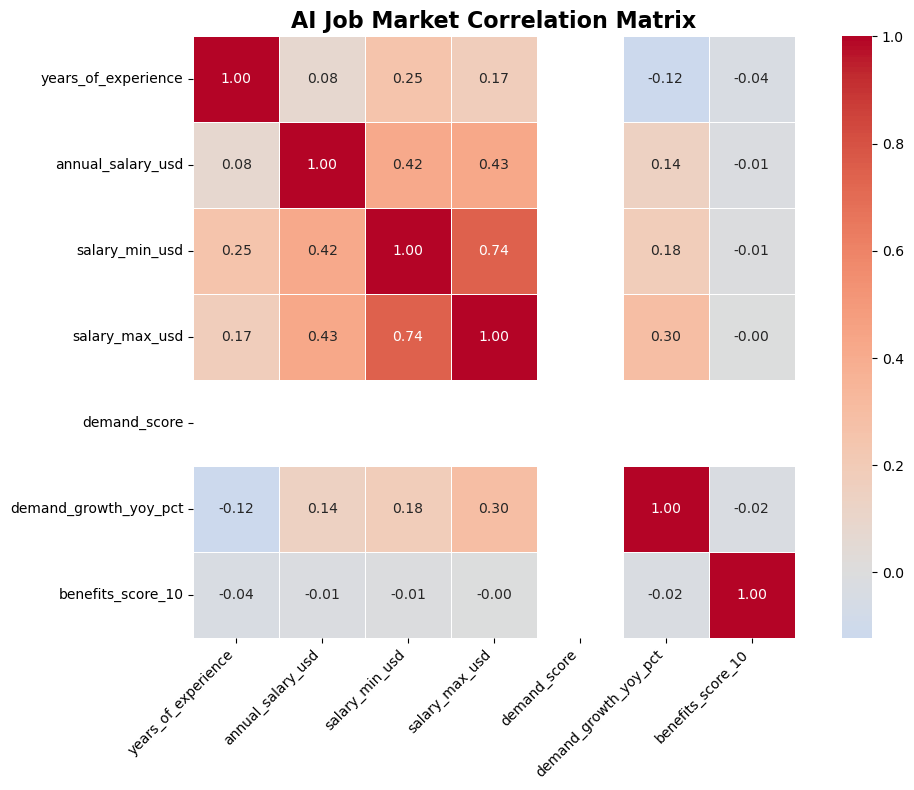

In [87]:
# 20. Correlation Analysis
# Select numerical columns
numeric_columns = [
    "years_of_experience",
    "annual_salary_usd",
    "salary_min_usd",
    "salary_max_usd",
    "demand_score",
    "demand_growth_yoy_pct",
    "benefits_score_10"
]

# Create correlation matrix


correlation_matrix = (
    df[numeric_columns]
    .corr()
)

# Display correlation matrix
display(correlation_matrix.round(2))


# Create heatmap

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title(
    "AI Job Market Correlation Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## ### Business Insight

The analysis shows that salary varies significantly across
experience groups. Senior and expert-level positions command
higher compensation compared with entry-level positions.

### Business Implication

Professionals with greater experience may have stronger
earning potential in the AI job market.

# Key EDA Findings

## Market
- Total AI job postings: ...

## Salary
- Average salary: ...
- Median salary: ...

## Skills
- Most demanded skill: ...

## Jobs
- Most common job role: ...

## Countries
- Highest job volume country: ...
- Highest salary country: ...

## Remote Work
- Remote job percentage: ...

## LLM / GenAI
- LLM job count: ...
- LLM salary comparison: ...



## Trends
- Job market growth: ...